# Predicting Customer Satisfaction with Imbalanced Data and Hyperparameter Optimization

In a [previous notebook](https://www.kaggle.com/solegalli/customer-satisfaction-with-imbalanced-data) I applied various techniques to improve the performance of models trained on imbalanced datasets. I applied each technique separately, searching for the best hyperparameters in each case, using randomized search.

**But what if, the technique to improve model performance was in itself another hyperparameter?**

**What if we could write code, that automatically was able to find which technique would work best in our data?**

This is what we are going to do in this notebooks. We will write code where each technique is an additional hyperparameter that we can optimize. And because now training the models turns more computationally costly and we have more hyperparameters, instead of Randomized search we will performe Bayesian optimization of the hyperparameters, a method that guides the search towards more promising values of the hyperparameters.

We will use Optuna for the optimization, because it allows us to define hyperparameters on the fly, with its "define-by-run" API design.

So, let's get started!

PS: If you want to know more about hyperparameter optimization or working with imbalanced datasets, feel free to check my [online courses](https://www.trainindata.com/).


In [1]:
# Let's install Feature-engine
# this package will allow us to quickly remove 
# non-predictive variables

!pip install feature-engine

     |████████████████████████████████| 180 kB 937 kB/s 


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# to sample the hyperparameter space based on distributions
from scipy import stats

# I use GBM because it usually out-performs other off-the-shelf 
# classifiers
from sklearn.ensemble import GradientBoostingClassifier

# metric to optimize for the competition
from sklearn.metrics import roc_auc_score

# to optimize the hyperparameters we import the randomized search class
from sklearn.model_selection import (
    cross_val_score,
    train_test_split,
)

# to assemble various procedures in sequence
from sklearn.pipeline import Pipeline

# some methods to work with imbalanced data are based in nearest neighbours
# and nearest neighbours are sensitive to the magnitude of the features
# so we need to scale the data
from sklearn.preprocessing import MinMaxScaler

# import selection classes from Feature-engine
# to reduce the number of features
from feature_engine.selection import (
    DropDuplicateFeatures,
    DropConstantFeatures,
)


# over-sampling techniques for imbalanced data
from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTENC,
)

# under-sampling techniques for imbalanced data
from imblearn.under_sampling import (
    RandomUnderSampler,
    InstanceHardnessThreshold,
)

# special ensemble methods to work with imbalanced data
# we will use those based on boosting, which tend to work better
from imblearn.ensemble import (
    RUSBoostClassifier,
    EasyEnsembleClassifier,
)

# to put the undersampling methods and the GBM together
from imblearn.pipeline import make_pipeline

import optuna

## Load the data

In [3]:
# load the Santander Customer Satisfaction dataset

data = pd.read_csv('/kaggle/input/santander-customer-satisfaction/train.csv')

In [4]:
# separate dataset into train and test sets
# I split 30:70 mostly to reduce the size of the train set
# so that this notebook does not run out of memory :_(

X_train, X_test, y_train, y_test = train_test_split(
    data.drop(labels=['ID','TARGET'], axis=1),
    data['TARGET'],
    test_size=0.7,
    random_state=0)

X_train.shape, X_test.shape

((22806, 369), (53214, 369))

## Target

The target class is imbalanced. The value 1 refers to un-satisfied customers and 0 to satisfied. So most of Santander's customers are satisfied.

In [5]:
# check class imbalance

y_train.value_counts(normalize=True), y_train.value_counts()

(0    0.960361
 1    0.039639
 Name: TARGET, dtype: float64,
 0    21902
 1      904
 Name: TARGET, dtype: int64)

## Drop constant and duplicated features

This dataset contains constant and duplicated features. I know this from previous analysis so I will quickly remove these features to reduce the data size.

I will also remove quasi-constant features to reduce the size of the data set, otherwise the kernel runs out of memory.

More insight about feature selection for this dataset here: https://www.kaggle.com/solegalli/feature-selection-with-feature-engine


In [6]:
# to remove constant, quasi-constant and duplicated features
# we use the transformers from Feature-engine

pipe = Pipeline([
    ('constant', DropConstantFeatures(tol=0.98)), # drops constant and quasi-constant features
    ('duplicated', DropDuplicateFeatures()), # drops duplicates
])

# find features to remove
pipe.fit(X_train, y_train)

Pipeline(steps=[('constant', DropConstantFeatures(tol=0.98)),
                ('duplicated', DropDuplicateFeatures())])

In [7]:
print('Number of original variables: ', X_train.shape[1])

# see how with the pipeline we can apply all transformers in sequence
# with one line of code, for each data set
X_train = pipe.transform(X_train)
X_test = pipe.transform(X_test)

print('Number of variables after selection: ', X_train.shape[1])

Number of original variables:  369
Number of variables after selection:  130


Note how we reduced the size from almost 370 to 130 features.

## Techniques for imbalanced data

We will test the following methods:

* Random Oversampling
* Creating synthetic observations with SMOTE
* Random Undersampling
* Cleaning noisy observations with Instance Hardness
* RUSBoost, special ensemble models for imbalanced data
* Easy Ensemble, special ensemble models for imbalanced data
* Vanilla GBM
* GBM with cost sensitive learning


We start by writing the objective function that we want to optimize, which takes:

* the hyperparameters
* the models
* the metric to optimize
* the cross-validation scheme

In [8]:
# we need to capture the index of the discrete variables
# for SMOTENC

# make list of discrete variables
cat_vars = [var for var in X_train.columns if X_train[var].nunique() <= 10]

# capture the index in the dataframe columns
cat_vars_index = [cat_vars.index(x) for x in cat_vars]

cat_vars_index[0:6]

[0, 1, 2, 3, 4, 5]

In [9]:
# the objective function takes the hyperparameter space
# as input, which in Optuna is given by the trial object

def objective(trial):
    
    # the method to use is a hyperparameter to optimize
    method = trial.suggest_categorical(
        "method",["ros", "smote",'rus', 'iht',
                  'rusboost', 'easyensemble',
                  'gbm', 'cost_sensitive'],
    )
    
    
    if method == "ros":
        
        model = make_pipeline(
            
            # random oversampling
            RandomOverSampler(random_state=1),
            
            # GBM
            GradientBoostingClassifier(
                n_estimators = trial.suggest_int("ros_n_estimators", 10, 200),
                max_depth = trial.suggest_int("ros_max_depth", 1, 5),
                learning_rate = trial.suggest_float('ros_learning_rate', 0.0001, 1),
                random_state=0,
            )
        )
        
    if method == "smote":
        
        model = make_pipeline(
            
            # scaler
            MinMaxScaler(),
            
            # smote
            SMOTENC(random_state=0,
                   categorical_features=cat_vars_index,
                   ),
            
            # GBM
            GradientBoostingClassifier(
                n_estimators = trial.suggest_int("smote_n_estimators", 10, 200),
                max_depth = trial.suggest_int("smote_max_depth", 1, 5),
                learning_rate = trial.suggest_float('smote_learning_rate', 0.0001, 1),
                random_state=0,
            )
        )
        
    if method == 'rus':
        
        model = make_pipeline(
            
            # random undersampling
            RandomUnderSampler(random_state=1),
            
            # GBM
            GradientBoostingClassifier(
                n_estimators = trial.suggest_int("rus_n_estimators", 10, 200),
                max_depth = trial.suggest_int("rus_max_depth", 1, 5),
                learning_rate = trial.suggest_float('rus_learning_rate', 0.0001, 1),
                random_state=0,
            )
        )
        
    if method == 'iht':
        
        gbm = GradientBoostingClassifier(
                n_estimators = trial.suggest_int("iht_n_estimators", 10, 200),
                max_depth = trial.suggest_int("iht_max_depth", 1, 5),
                learning_rate = trial.suggest_float('iht_learning_rate', 0.0001, 1),
                random_state=0,
            )
            
        model = make_pipeline(
            
            # instance hardness threshold
            InstanceHardnessThreshold(
                estimator = gbm,
                random_state = 1,
                cv = 2,  # cross validation fold, 2 to speed things up.
            ),
        
            # GBM
            gbm,
        )
        
        
    if method == 'rusboost':
        
        model = RUSBoostClassifier(
            n_estimators = trial.suggest_int("rusboost_n_estimators", 5, 30),
            learning_rate = trial.suggest_float('rusboost_learning_rate', 0.0001, 1),
            random_state = 2909,
    )
        
    if method=='easyensemble':       

        model = EasyEnsembleClassifier(
                n_estimators = trial.suggest_int("easy_n_estimators", 5, 30),
                random_state = 2909,
            )
        
    if method == 'gbm':
        
        model = GradientBoostingClassifier(
                    n_estimators = trial.suggest_int("gbm_n_estimators", 10, 200),
                    max_depth = trial.suggest_int("gbm_max_depth", 1, 5),
                    learning_rate = trial.suggest_float('gbm_learning_rate', 0.0001, 1),
                    random_state = 0,
            )

    
    if method == 'cost_sensitive':
        
        model = GradientBoostingClassifier(
                    n_estimators = trial.suggest_int("cs_n_estimators", 10, 200),
                    max_depth = trial.suggest_int("cs_max_depth", 1, 5),
                    learning_rate = trial.suggest_float('cs_learning_rate', 0.0001, 1),
                    random_state = 0,
            )
        
        sample_weight = np.where(y_train == 1, 95, 5)
        
        score = cross_val_score(
            estimator = model,
            X = X_train,
            y = y_train,
            fit_params = {'sample_weight': sample_weight},
            scoring='roc_auc',
            cv=3,
        )
    
    else: 
        
        score = cross_val_score(model, X_train, y_train, scoring='roc_auc', cv=3)
    
    roc = score.mean()
    
    return roc

In [10]:
# we set up the study
study = optuna.create_study(
    direction="maximize",
)


# and now we want to maximize the roc-auc
# we run 15 trials otherwise the kernel runs out of memory.

# the more trials we run the greater the chances to find the best hyperparams

study.optimize(objective, n_trials=15)

[I 2021-10-15 16:27:50,568] A new study created in memory with name: no-name-7a38d6bb-6148-45c4-ae3f-0934c6c923fc
[I 2021-10-15 16:27:52,800] Trial 0 finished with value: 0.8090828345832838 and parameters: {'method': 'rus', 'rus_n_estimators': 83, 'rus_max_depth': 4, 'rus_learning_rate': 0.29475863836956}. Best is trial 0 with value: 0.8090828345832838.
[I 2021-10-15 16:27:54,264] Trial 1 finished with value: 0.82703495228259 and parameters: {'method': 'rusboost', 'rusboost_n_estimators': 22, 'rusboost_learning_rate': 0.3374079069603697}. Best is trial 1 with value: 0.82703495228259.
[I 2021-10-15 16:28:14,606] Trial 2 finished with value: 0.8339624232208068 and parameters: {'method': 'ros', 'ros_n_estimators': 39, 'ros_max_depth': 4, 'ros_learning_rate': 0.046770498480437774}. Best is trial 2 with value: 0.8339624232208068.
[I 2021-10-15 16:29:19,340] Trial 3 finished with value: 0.7884197713330156 and parameters: {'method': 'iht', 'iht_n_estimators': 150, 'iht_max_depth': 5, 'iht_lea

In [11]:
# we find the best parameters here

study.best_params

{'method': 'ros',
 'ros_n_estimators': 39,
 'ros_max_depth': 4,
 'ros_learning_rate': 0.046770498480437774}

In [12]:
# the best roc-auc

study.best_value

0.8339624232208068

In [13]:
# we can find out how many of each method the search tested

results = study.trials_dataframe()

results['params_method'].value_counts()

rus               3
ros               3
gbm               3
rusboost          2
iht               2
cost_sensitive    1
easyensemble      1
Name: params_method, dtype: int64

Text(0, 0.5, 'ROC-AUC')

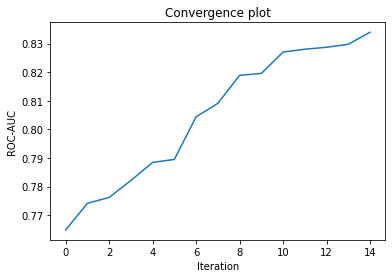

In [14]:
# we can plot the maximization of the roc-auc

results['value'].sort_values().reset_index(drop=True).plot()
plt.title('Convergence plot')
plt.xlabel('Iteration')
plt.ylabel('ROC-AUC')